In [2]:
import pandas as pd
import matplotlib.pyplot as plt


# -------------------------------------------------------------
# STEP 1: Load Dataset
# -------------------------------------------------------------

print("\nSTEP 1: Loading Dataset\n")

df = pd.read_csv("raw_metadata.csv")

print(df.head())
print("\nDataset Shape:", df.shape)




STEP 1: Loading Dataset

      video_id                                              title  \
0  E-CH3-VyVck  🚀 Why is Git INSANELY Fast? (And How Commits A...   
1  -l0ZsmMdZYE       One click deploys vs manual K8s hell #devops   
2  URI5GsOBznk  YouTube Recommendation Engine: Complete Meltdo...   
3  8d2eG7bdepQ  Implementing OAuth and MFA: Full Authenticatio...   
4  GQ6piqfwr5c  How Stripe Built AI Agents That Write 1,000+ P...   

           publish_date  
0  2026-02-24T11:00:29Z  
1  2026-02-23T03:44:26Z  
2  2026-02-21T04:26:16Z  
3  2026-02-18T11:00:16Z  
4  2026-02-14T13:02:10Z  

Dataset Shape: (400, 3)


In [3]:
# -------------------------------------------------------------
# STEP 2: Understand Dataset Structure
# -------------------------------------------------------------

print("\nSTEP 2: Dataset Structure\n")

print("Columns:", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nTotal Rows:", len(df))

required_columns = ["video_id", "title", "publish_date"]

for col in required_columns:
    print(f"{col} exists:", col in df.columns)



STEP 2: Dataset Structure

Columns: ['video_id', 'title', 'publish_date']

Data Types:
 video_id        str
title           str
publish_date    str
dtype: object

Total Rows: 400
video_id exists: True
title exists: True
publish_date exists: True


In [4]:
# -------------------------------------------------------------
# STEP 3: Check for Duplicate Entries
# -------------------------------------------------------------

print("\nSTEP 3: Checking Duplicates\n")

dup_video_ids = df["video_id"].duplicated().sum()
dup_titles = df["title"].duplicated().sum()

print("Duplicate video_id count:", dup_video_ids)
print("Duplicate title count:", dup_titles)



STEP 3: Checking Duplicates

Duplicate video_id count: 0
Duplicate title count: 2


In [5]:
# Remove duplicate video_id entries
df = df.drop_duplicates(subset="video_id")

print("Shape after removing duplicate video_ids:", df.shape)


Shape after removing duplicate video_ids: (400, 3)


In [6]:
# -------------------------------------------------------------
# STEP 4: Check for Missing Values
# -------------------------------------------------------------

print("\nSTEP 4: Checking Missing Values\n")

print(df[["video_id", "title", "publish_date"]].isnull().sum())



STEP 4: Checking Missing Values

video_id        0
title           0
publish_date    0
dtype: int64


In [7]:
# Drop rows with missing critical values
df = df.dropna(subset=["video_id", "title", "publish_date"])

print("Shape after removing null values:", df.shape)

Shape after removing null values: (400, 3)


In [8]:
# -------------------------------------------------------------
# STEP 5: Convert Publish Date to Datetime
# -------------------------------------------------------------

print("\nSTEP 5: Converting Publish Date\n")

df["publish_date"] = pd.to_datetime(df["publish_date"])

df["year"] = df["publish_date"].dt.year
df["month"] = df["publish_date"].dt.month

print(df[["publish_date", "year", "month"]].head())


STEP 5: Converting Publish Date

               publish_date  year  month
0 2026-02-24 11:00:29+00:00  2026      2
1 2026-02-23 03:44:26+00:00  2026      2
2 2026-02-21 04:26:16+00:00  2026      2
3 2026-02-18 11:00:16+00:00  2026      2
4 2026-02-14 13:02:10+00:00  2026      2


In [9]:
# -------------------------------------------------------------
# STEP 6: Analyze Publish Frequency
# -------------------------------------------------------------

print("\nSTEP 6: Publish Frequency Analysis\n")

videos_per_year = df["year"].value_counts().sort_index()
videos_per_month = df["month"].value_counts().sort_index()

print("Videos Per Year:\n", videos_per_year)
print("\nVideos Per Month:\n", videos_per_month)


STEP 6: Publish Frequency Analysis

Videos Per Year:
 year
2023     27
2024    196
2025    161
2026     16
Name: count, dtype: int64

Videos Per Month:
 month
1     37
2     27
3     17
4     23
5     21
6     19
7     26
8     42
9     51
10    49
11    48
12    40
Name: count, dtype: int64


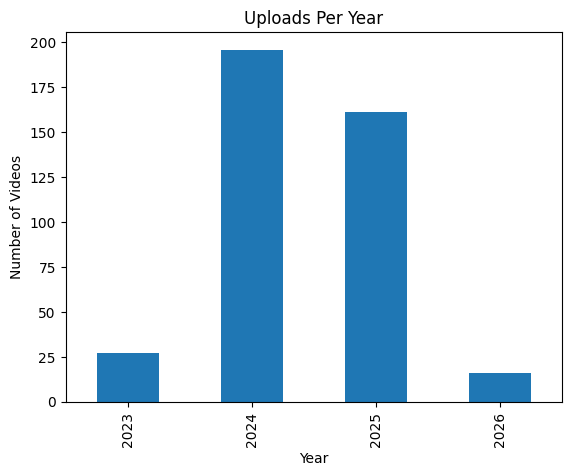

In [10]:
# Bar chart of uploads per year
plt.figure()
videos_per_year.plot(kind="bar")
plt.xlabel("Year")
plt.ylabel("Number of Videos")
plt.title("Uploads Per Year")
plt.show()

In [11]:
# -------------------------------------------------------------
# STEP 7: Analyze Title Distribution
# -------------------------------------------------------------

print("\nSTEP 7: Title Distribution Analysis\n")

df["title_length"] = df["title"].apply(len)

print("Shortest title length:", df["title_length"].min())
print("Longest title length:", df["title_length"].max())
print("Average title length:", df["title_length"].mean())



STEP 7: Title Distribution Analysis

Shortest title length: 12
Longest title length: 95
Average title length: 49.97


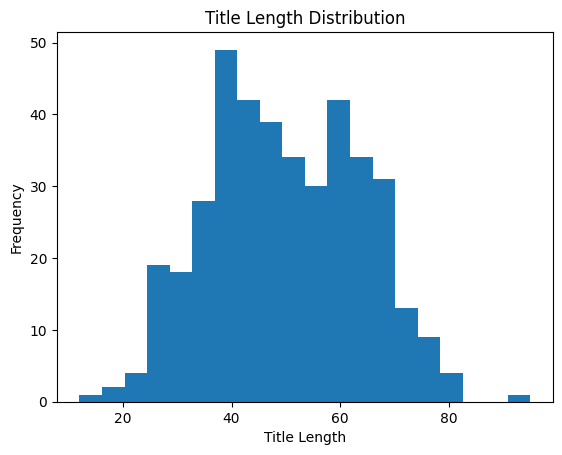

In [12]:
# Histogram of title lengths
plt.figure()
df["title_length"].plot(kind="hist", bins=20)
plt.xlabel("Title Length")
plt.ylabel("Frequency")
plt.title("Title Length Distribution")
plt.show()

In [13]:
# -------------------------------------------------------------
# STEP 8: Verify Dataset Size & Scope
# -------------------------------------------------------------

print("\nSTEP 8: Dataset Size & Scope\n")

print("Total Unique Videos:", df["video_id"].nunique())
print("Date Range:")
print("Start:", df["publish_date"].min())
print("End:", df["publish_date"].max())
print("Final Dataset Shape:", df.shape)


STEP 8: Dataset Size & Scope

Total Unique Videos: 400
Date Range:
Start: 2023-01-21 10:00:12+00:00
End: 2026-02-24 11:00:29+00:00
Final Dataset Shape: (400, 6)


In [14]:
print("\nSTEP 9: Cleaning Titles\n")

df["title"] = df["title"].str.replace("\n", " ", regex=False)
df["title"] = df["title"].str.strip()
df["title"] = df["title"].str.replace(r"\s+", " ", regex=True)

print("Titles cleaned successfully.")



STEP 9: Cleaning Titles

Titles cleaned successfully.


In [15]:
# -------------------------------------------------------------
# STEP 10: Save Cleaned Dataset
# -------------------------------------------------------------

df.to_csv("cleaned_metadata.csv", index=False)

print("\ncleaned_metadata.csv saved successfully.")


cleaned_metadata.csv saved successfully.
